![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [70]:
import warnings
warnings.filterwarnings('ignore')

In [72]:
# Importación de librerías
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz, DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, f1_score, roc_curve, roc_auc_score
from sklearn.utils import resample

In [74]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [76]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

Tabla con Estadísticas:
Estación
              mean  median         std  min  max   p25    p75
season                                                       
1       116.343261    78.0  125.273974    1  801  24.0  164.0
2       215.251372   172.0  192.007843    1  873  49.0  321.0
3       234.417124   195.0  197.151001    1  977  68.0  347.0
4       198.988296   161.0  177.622409    1  948  51.0  294.0

Gráfica de promedio por estación


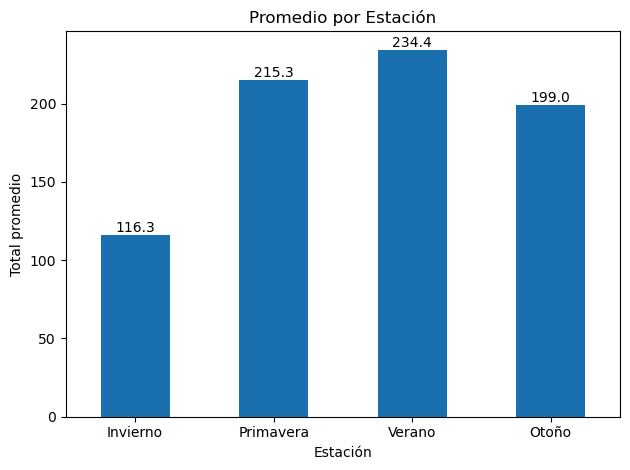

In [78]:
#Validar el comportamiento del arrendamiento de bicicletas por las diferentes estaciones
print("Tabla con Estadísticas:")
print("Estación")
season_stats = bikes.groupby('season')['total'].agg(['mean', 'median', 'std', 'min', 'max',
                                                      lambda x: x.quantile(0.25),
                                                      lambda x: x.quantile(0.75)])
season_stats.columns = ['mean', 'median', 'std', 'min', 'max', 'p25', 'p75']
print(season_stats.to_string())

print("\nGráfica de promedio por estación")
g_season = bikes.groupby('season')['total'].mean().plot(kind='bar', color='#1a6faf', title='Promedio por Estación')
plt.xticks(ticks=[0,1,2,3], labels=['Invierno','Primavera','Verano','Otoño'], rotation=0)
plt.ylabel('Total promedio')
plt.xlabel('Estación')
for p in g_season.patches:
    g_season.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Conclusión

* Se puede observar que la estación donde más se arriendan bicicletas es en **verano**, con un promedio de 234.4 bicicletas, y el mes en el que menos arrendamiento de bicicletas se da es en **invierno**, con un promedio de 116.3 bicicletas. Por lo cual se podría intuir que por el clima más frío en invierno, las personas reducen su demanda de arrendar bicicletas.

In [80]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

Tabla con Estadísticas
Hora
            mean  median         std  min  max     p25     p75
hour                                                          
0      55.138462    41.0   43.620012    2  283   24.00   74.50
1      33.859031    19.0   34.112105    1  168   11.00   46.00
2      22.899554    11.0   26.110267    1  119    5.00   32.00
3      11.757506     6.0   12.666442    1   66    3.00   15.00
4       6.407240     6.0    4.217633    1   28    3.00    9.00
5      19.767699    19.0   12.784293    1   57    8.00   29.00
6      76.259341    75.0   54.745333    1  213   24.50  118.00
7     213.116484   208.0  159.207044    1  596   63.00  334.00
8     362.769231   392.0  231.723065    8  839  133.50  563.50
9     221.780220   217.0   92.099209   14  414  161.00  294.50
10    175.092308   149.0  101.807629   17  539  106.00  218.50
11    210.674725   183.0  127.444294   10  647  123.00  265.50
12    256.508772   234.5  143.881880    3  757  157.00  332.00
13    257.787281   226.5  1

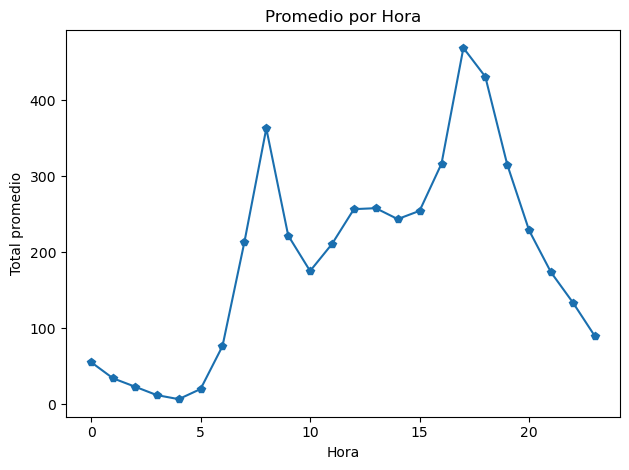

In [15]:
#Validar el comportamiento del arrendamiento de bicicletas por las diferentes horas del día
print("Tabla con Estadísticas")
print("Hora")
hour_stats = bikes.groupby('hour')['total'].agg(['mean', 'median', 'std', 'min', 'max',
                                                  lambda x: x.quantile(0.25),
                                                  lambda x: x.quantile(0.75)])
hour_stats.columns = ['mean', 'median', 'std', 'min', 'max', 'p25', 'p75']
print(hour_stats.to_string())

print("\nGráfica de promedio por hora\n")
bikes.groupby('hour')['total'].mean().plot(kind='line', color='#1a6faf', marker='p', title='Promedio por Hora')
plt.xlabel('Hora')
plt.ylabel('Total promedio')
plt.tight_layout()
plt.show()

### Conclusión

* Podemos observar dos picos dentro de toda la franja horaria, en la hora de la mañana, más o menos a las 7 am, y en la hora de la tarde, más o menos de 5- 6 pm; lo que puede indicar que la gente utiliza las bicicletas para poder realizar el desplazamiento entre trabajo - casa.

* Las horas donde menos se utiliza el servicio de arrendmaiento de bicicletas es en la franja de 3 - 5 am.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

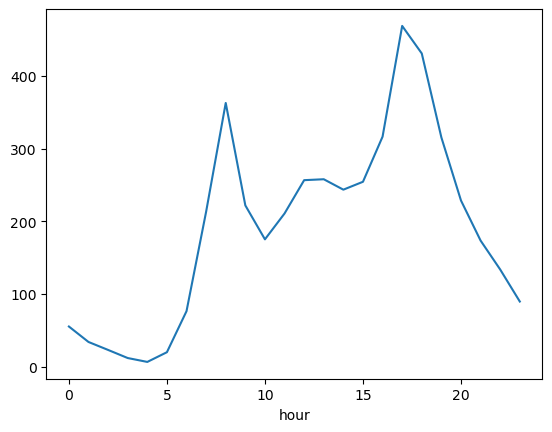

In [83]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()
plt.show()

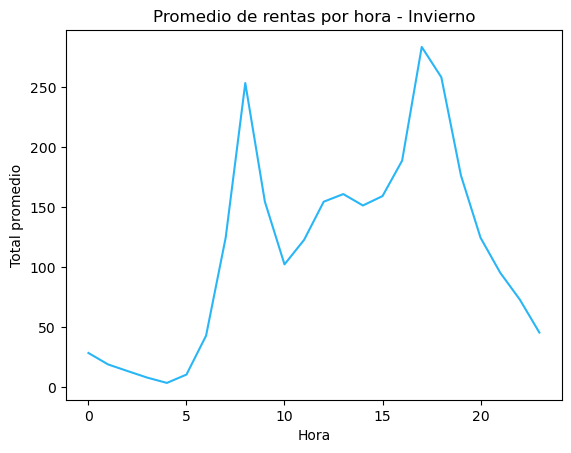

In [85]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
bikes[bikes['season'] == 1].groupby('hour')['total'].mean().plot(
    title='Promedio de rentas por hora - Invierno', color='#29b6f6')
plt.xlabel('Hora')
plt.ylabel('Total promedio')
plt.show()

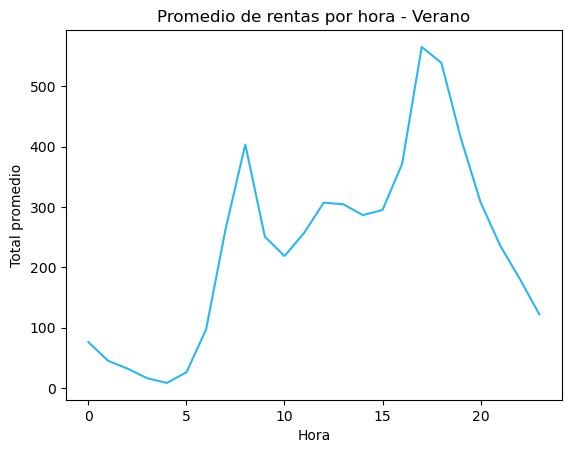

In [133]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
bikes[bikes['season'] == 3].groupby('hour')['total'].mean().plot(
    title='Promedio de rentas por hora - Verano', color='#29b6f6')
plt.xlabel('Hora')
plt.ylabel('Total promedio')
plt.show()

### Conslución

* Podemos observar gráficamente el comportamiento del arrendamiento de bicicletas en el total del año y por las estaciones de **invierno** y **verano**:

  * ***Invierno:*** Se mantienen los picos de la mañana y la tarde, pero en menor cantidad, ya que la demanda de bicicletas en esta estación es notablemente más baja que el promedio general.

  * ***Verano:*** Se mantienen los picos de la mañana y la tarde, con una mayor cantidad en la tarde. Se presenta una mayor actividade en las horas de 10 am - 3 pm.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [88]:
# Celda 3
#Variables predictoras: season y hour
X = pd.get_dummies(bikes[['season', 'hour']], columns=['season'], drop_first=True)
y = bikes['total']

#Dividir base en conjuntos de train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#Modelo Lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)

#Coeficientes
coefs = pd.Series(modelo.coef_, index=X.columns)
print("Intercepto:", round(modelo.intercept_, 2))
print("\nCoeficientes:\n", coefs.round(2))

Intercepto: -6.86

Coeficientes:
 hour         10.54
season_2     99.25
season_3    118.61
season_4     86.35
dtype: float64


### Conslusión 

El modelo confirma que el verano (season_3) es la estación con más demanda y que la hora tiene efecto positivo, pero al ser lineal no logra capturar el comportamiento real de los dos picos que se evidenciaron previamente en el punto 2.

Interpretación de los coeficientes:

* **Intercepto (-6.86):** en invierno a las 0 horas el modelo predice -6.86 rentas, valor negativo que no tiene sentido.
* **hour (10.54):** por cada hora que avanza el día, el modelo estima ~10.54 rentas adicionales. Se asume un crecimiento constante, no tiene en cuenta los dos picos (8am y 5pm).
* **season_2 (99.25):** en primavera se rentan ~99 bicicletas más que en invierno.
* **season_3 (118.61):** en verano se rentan ~119 bicicletas más que en invierno.
* **season_4 (86.35):** en otoño se rentan ~86 bicicletas más que en invierno.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [90]:
# Celda 4
#Selección de variables predictoras y variable objetivo
X = pd.get_dummies(bikes[['season', 'hour']], columns=['season'], drop_first=True)
#Convertir a numéricas para poder procesar el árbol
X = X.astype(float)

y = bikes['total']

In [139]:
X.head

<bound method NDFrame.head of                      hour  season_2  season_3  season_4
datetime                                               
2011-01-01 00:00:00   0.0       0.0       0.0       0.0
2011-01-01 01:00:00   1.0       0.0       0.0       0.0
2011-01-01 02:00:00   2.0       0.0       0.0       0.0
2011-01-01 03:00:00   3.0       0.0       0.0       0.0
2011-01-01 04:00:00   4.0       0.0       0.0       0.0
...                   ...       ...       ...       ...
2012-12-19 19:00:00  19.0       0.0       0.0       1.0
2012-12-19 20:00:00  20.0       0.0       0.0       1.0
2012-12-19 21:00:00  21.0       0.0       0.0       1.0
2012-12-19 22:00:00  22.0       0.0       0.0       1.0
2012-12-19 23:00:00  23.0       0.0       0.0       1.0

[10886 rows x 4 columns]>

In [92]:
#Parámetros del árbol
max_depth = None
num_pct = 10
min_gain = 0.001

In [94]:
#Función para calcular varianza
def mse(y):
    
    if y.shape[0] == 0:
        return 0
    else:
        return np.var(y)

In [96]:
#Función para garantizar ganancia del split
def mse_impurity(X_col, y, split):
    
    filter_l = X_col < split
    
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    n_l = y_l.shape[0]
    n_r = y_r.shape[0]
    
    mse_y = mse(y)
    mse_l = mse(y_l)
    mse_r = mse(y_r)
    
    mse_impurity_ = mse_y - (n_l/(n_l+n_r)*mse_l + n_r/(n_l+n_r)*mse_r)
    
    return mse_impurity_

In [98]:
#Buscar mejor variable y punto de corte 
def best_split(X, y, num_pct=10):
    
    features = range(X.shape[1])
    
    best_split = [0,0,0]  #j,split,gain
    
    for j in features:
        
        splits = np.percentile(X.iloc[:,j],
                               np.arange(0,100,100.0/(num_pct+1)).tolist())
        
        splits = np.unique(splits)[1:]
        
        for split in splits:
            
            gain = mse_impurity(X.iloc[:,j], y, split)
            
            if gain > best_split[2]:
                best_split = [j, split, gain]
                
    return best_split

In [100]:
#Función para crecer árbol
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    
    #predicción del nodo
    y_pred = y.mean()
    
    tree = dict(y_pred=y_pred, level=level, split=-1,
                n_samples=X.shape[0], gain=0)
    
    #buscar mejor split
    j, split, gain = best_split(X, y, num_pct)
    
    tree['gain'] = gain
    
    #criterio de parada
    if gain < min_gain:
        return tree
    
    if max_depth is not None:
        if level >= max_depth:
            return tree
    
    #dividir datos
    filter_l = X.iloc[:,j] < split
    
    X_l = X.loc[filter_l]
    y_l = y.loc[filter_l]
    
    X_r = X.loc[~filter_l]
    y_r = y.loc[~filter_l]
    
    tree['split'] = [j, split]
    
    #crecer ramas
    tree['sl'] = tree_grow(X_l, y_l, level+1,
                           min_gain=min_gain,
                           max_depth=max_depth,
                           num_pct=num_pct)
    
    tree['sr'] = tree_grow(X_r, y_r, level+1,
                           min_gain=min_gain,
                           max_depth=max_depth,
                           num_pct=num_pct)
    
    return tree

In [102]:
#Crear árbol
tree = tree_grow(X, y, level=0, min_gain=0.001, max_depth=3, num_pct=10)

tree

{'y_pred': 191.57413191254824,
 'level': 0,
 'split': [0, 8.0],
 'n_samples': 10886,
 'gain': 9134.405911766378,
 'sl': {'y_pred': 55.437673900946024,
  'level': 1,
  'split': [0, 7.0],
  'n_samples': 3594,
  'gain': 3603.850329979806,
  'sl': {'y_pred': 32.58203249442498,
   'level': 2,
   'split': [0, 6.0],
   'n_samples': 3139,
   'gain': 323.4004463794806,
   'sl': {'y_pred': 25.177719821162444,
    'level': 3,
    'split': -1,
    'n_samples': 2684,
    'gain': 191.40441543022723},
   'sr': {'y_pred': 76.25934065934067,
    'level': 3,
    'split': -1,
    'n_samples': 455,
    'gain': 140.78707852207936}},
  'sr': {'y_pred': 213.11648351648353,
   'level': 2,
   'split': [2, 1.0],
   'n_samples': 455,
   'gain': 866.7691640814373,
   'sl': {'y_pred': 196.09384164222874,
    'level': 3,
    'split': -1,
    'n_samples': 341,
    'gain': 656.9912596996837},
   'sr': {'y_pred': 264.03508771929825,
    'level': 3,
    'split': -1,
    'n_samples': 114,
    'gain': 0}}},
 'sr': {'y_pr

In [104]:
#Función para predecir
def tree_predict(X, tree):
    
    predicted = np.zeros(X.shape[0])
    
    if tree['split'] == -1:
        predicted[:] = tree['y_pred']
        
    else:
        
        j, split = tree['split']
        
        filter_l = X.iloc[:,j] < split
        
        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]
        
        if X_l.shape[0] > 0:
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
            
        if X_r.shape[0] > 0:
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])
    
    return predicted

In [106]:
#Predicciones del árbol
pred = tree_predict(X, tree)

pred[:10]

array([ 25.17771982,  25.17771982,  25.17771982,  25.17771982,
        25.17771982,  25.17771982,  76.25934066, 196.09384164,
       247.79994512, 247.79994512])

In [108]:
#Calcular MSE
mse = np.mean((y - pred)**2)

print("MSE:", mse)

MSE: 18368.541897854844


### Conclusión

El árbol de decisión construido manualmente con las variables predictoras **hour** y **season** permite estimar el número de préstamos de bicicletas. El modelo obtuvo un MSE de 18368.54, lo que indica que existe una diferencia considerable entre los valores reales y los predichos.

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [110]:
# Celda 5
#Selección de variables predictoras y variable objetivo
#Variables predictoras
X = pd.get_dummies(bikes[['season','hour']], columns=['season'], drop_first=True)

#Variable objetivo
y = bikes['total']

In [112]:
#Dividir base en train y test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [114]:
#Entrenar árbol de decisión
tree_model = DecisionTreeRegressor(
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)

tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=6, min_samples_leaf=20, random_state=42)

In [116]:
#Predicciones
y_pred = tree_model.predict(X_test)

In [118]:
#Calcular MSE
mse_tree = mean_squared_error(y_test, y_pred)

print("MSE árbol sklearn:", mse_tree)

MSE árbol sklearn: 15225.79633711743


### Conclusión

El árbol de decisión entrenado con la librería sklearn obtuvo un MSE de 15225.80, el cual es menor que el obtenido con el árbol construido manualmente (18368.54). Esto indica que el modelo implementado con sklearn presenta un mejor desempeño predictivo.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [120]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [122]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

0.5

In [124]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [126]:
# Celda 6
#Árbol de Desición
tree_model = DecisionTreeClassifier(
    max_depth=6, 
    random_state=1
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:,1]

#Métricas
acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("Árbol de decisión")
print("Accuracy:", acc_tree)
print("F1-score:", f1_tree)

Árbol de decisión
Accuracy: 0.626
F1-score: 0.6227303295225286


In [128]:
#Regresión Logística
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

#Métricas
acc_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Regresión logística")
print("Accuracy:", acc_log)
print("F1-score:", f1_log)

Regresión logística
Accuracy: 0.6146666666666667
F1-score: 0.6024759284731774


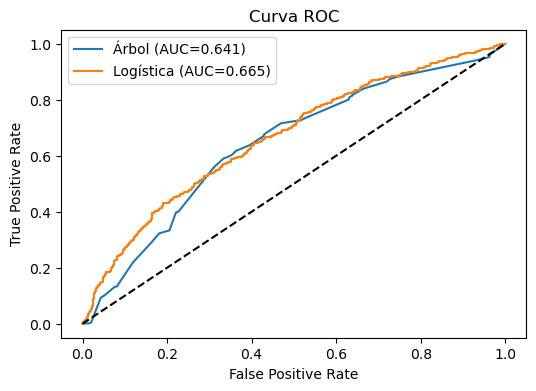

In [130]:
#Curva ROC- AUC modelos predichos
auc_tree = roc_auc_score(y_test, y_prob_tree)
auc_log = roc_auc_score(y_test, y_prob_log)

fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(6,4))

plt.plot(fpr_tree, tpr_tree, label="Árbol (AUC="+str(round(auc_tree,3))+")")
plt.plot(fpr_log, tpr_log, label="Logística (AUC="+str(round(auc_log,3))+")")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")

plt.legend()
plt.show()

### Conclusión
Se entrenaron un **árbol de decisión** y una **regresión logística** para clasificar si una noticia es popular. El árbol de decisión obtuvo un Accuracy de 0.626 y un F1-score de 0.623, ligeramente mayores a los generados con la regresión logística, que alcanzó un Accuracy de 0.615 y un F1-score de 0.602. Sin embargo, al analizar la curva ROC, la regresión logística presentó un AUC mayor (0.665) en comparación con el árbol (0.641), lo que indica una mejor capacidad para discriminar entre noticias populares y no populares. En general, ambos modelos presentan un desempeño similar, aunque la regresión logística muestra una ligera ventaja en términos de capacidad de clasificación en las clases, según la gráfica de AUC.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [132]:
# Celda 7
#Listas para poder guardar las predicciones
pred_tree_depth = []
pred_tree_leaf = []
pred_log = []

#Listas para poder guardar las probabilidades
prob_tree_depth = []
prob_tree_leaf = []
prob_log = []

In [134]:
#100 árboles con max_depth
for i in range(100):

    X_boot, y_boot = resample(X_train, y_train, replace=True)

    model = DecisionTreeClassifier(max_depth=6, random_state=i)

    model.fit(X_boot, y_boot)

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    pred_tree_depth.append(pred)

    prob_tree_depth.append(prob)

In [136]:
#100 árboles con min_samples_leaf
for i in range(100):

    X_boot, y_boot = resample(X_train, y_train, replace=True)

    model = DecisionTreeClassifier(min_samples_leaf=20, random_state=i)

    model.fit(X_boot, y_boot)

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    pred_tree_leaf.append(pred)

    prob_tree_leaf.append(prob)

In [138]:
#100 regresiones logísticas
for i in range(100):

    X_boot, y_boot = resample(X_train, y_train, replace=True)

    model = LogisticRegression(max_iter=1000)

    model.fit(X_boot, y_boot)

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    pred_log.append(pred)

    prob_log.append(prob)

In [140]:
#Evaluar cada grupo de modelos
#Árboles max_depth
pred_depth = np.round(np.mean(pred_tree_depth, axis=0))

print("Árboles max_depth")
print("Accuracy:", accuracy_score(y_test, pred_depth))
print("F1-score:", f1_score(y_test, pred_depth))

#Árboles min_samples_leaf
pred_leaf = np.round(np.mean(pred_tree_leaf, axis=0))

print("\nÁrboles min_samples_leaf")
print("Accuracy:", accuracy_score(y_test, pred_leaf))
print("F1-score:", f1_score(y_test, pred_leaf))

#Regresiones logísticas
pred_log_avg = np.round(np.mean(pred_log, axis=0))

print("\nRegresiones logísticas")
print("Accuracy:", accuracy_score(y_test, pred_log_avg))
print("F1-score:", f1_score(y_test, pred_log_avg))

Árboles max_depth
Accuracy: 0.658
F1-score: 0.6536124240378123

Árboles min_samples_leaf
Accuracy: 0.662
F1-score: 0.6585858585858586

Regresiones logísticas
Accuracy: 0.6146666666666667
F1-score: 0.5991678224687933


In [142]:
#Ensamble final de los 300 modelos
#Juntar todas las predicicones
all_preds = pred_tree_depth + pred_tree_leaf + pred_log

#Realizar la votación mayoritaria sobre los 300 modelos
final_pred = np.round(np.mean(all_preds, axis=0))

In [144]:
#Evaluar ensamble
print("\nEnsable 300 modelos")

print("Accuracy:", accuracy_score(y_test, final_pred))
print("F1-score:", f1_score(y_test, final_pred))


Ensable 300 modelos
Accuracy: 0.6373333333333333
F1-score: 0.6263736263736264



AUC max_depth: 0.7163889600045515
AUC min_samples_leaf: 0.7212799396939181
AUC logística: 0.6668675684132672
AUC ensamble: 0.717633484098538


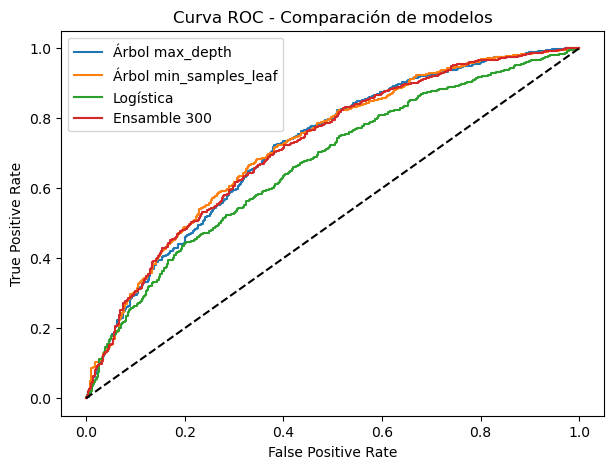

In [146]:
#Gráfica ROC - AUC
prob_depth = np.mean(prob_tree_depth, axis=0)
prob_leaf = np.mean(prob_tree_leaf, axis=0)
prob_log_avg = np.mean(prob_log, axis=0)

all_probs = prob_tree_depth + prob_tree_leaf + prob_log
prob_ensemble = np.mean(all_probs, axis=0)

print("\nAUC max_depth:", roc_auc_score(y_test, prob_depth))
print("AUC min_samples_leaf:", roc_auc_score(y_test, prob_leaf))
print("AUC logística:", roc_auc_score(y_test, prob_log_avg))
print("AUC ensamble:", roc_auc_score(y_test, prob_ensemble))

fpr_depth, tpr_depth, _ = roc_curve(y_test, prob_depth)
fpr_leaf, tpr_leaf, _ = roc_curve(y_test, prob_leaf)
fpr_log, tpr_log, _ = roc_curve(y_test, prob_log_avg)
fpr_ens, tpr_ens, _ = roc_curve(y_test, prob_ensemble)

plt.figure(figsize=(7,5))

plt.plot(fpr_depth, tpr_depth, label="Árbol max_depth")
plt.plot(fpr_leaf, tpr_leaf, label="Árbol min_samples_leaf")
plt.plot(fpr_log, tpr_log, label="Logística")
plt.plot(fpr_ens, tpr_ens, label="Ensamble 300")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Comparación de modelos")

plt.legend()
plt.show()

### Conclusión
Al realizar el ensamble de 300 modelos utilizando muestras bootstrap y votación mayoritaria, se observa que los árboles de decisión con el parámetro min_samples_leaf presentaron el mejor desempeño individual (Accuracy = 0.66, F1-score = 0.66), seguidos por los árboles con max_depth (Accuracy = 0.65, F1-score = 0.65). Las regresiones logísticas fueron el modelo individual con menor desempeño (Accuracy = 0.61, F1-score = 0.6).

El ensamble final de 300 modelos obtuvo un Accuracy de 0.63 y un F1-score de 0.62, mostrando un desempeño intermedio respecto a los modelos individuales. Esto indica que, que aunque el ensamble combina distintos modelos y reduce la variabilidad de las predicciones, no supera al modelo de los árboles de decisión con min_samples_leaf.

### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [148]:
# Celda 8
#Definir pesos
w_depth = 0.657
w_leaf = 0.660 #Se da más peso a este modelo ya que fue el que mejor desempeño tuvo individualmente
w_log = 0.619

In [150]:
#Predicciones promedio de cada modelo
pred_depth = np.round(np.mean(pred_tree_depth, axis=0))
pred_leaf = np.round(np.mean(pred_tree_leaf, axis=0))
pred_log_avg = np.round(np.mean(pred_log, axis=0))

In [152]:
#Votación ponderada
weighted_vote = (
    w_depth * pred_depth +
    w_leaf * pred_leaf +
    w_log * pred_log_avg
) / (w_depth + w_leaf + w_log)

final_weighted = np.round(weighted_vote)

In [154]:
#Evaluar modelo ensamblado
print("Ensamble ponderado")

print("Accuracy:", accuracy_score(y_test, final_weighted))
print("F1-score:", f1_score(y_test, final_weighted))

Ensamble ponderado
Accuracy: 0.6513333333333333
F1-score: 0.6444595513256288


### Conclusión
Para la construcción de modelo de ensamblaje por votación ponderada, se asigno al grupo de modelos un valor según su desempeño individual (el modelo con mayor ponderación es el de min_samples_leaf), esto dio como resultado un Accuracy de 0.65 y un F1-score de 0.65, mostrando una mejora frente al ensamble con votación mayoritaria construido en el punto anterior.

### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

In [156]:
# Celda 9
#Tabla comparativa
results = pd.DataFrame({
    "Modelo":[
        "Árboles max_depth",
        "Árboles min_samples_leaf",
        "Regresiones logísticas",
        "Ensamble votación mayoritaria",
        "Ensamble votación ponderada"
    ],
    "Accuracy":[
        0.657,
        0.660,
        0.619,
        0.637,
        0.654
    ],
    "F1-score":[
        0.656,
        0.660,
        0.607,
        0.628,
        0.650
    ]
})

results

,Modelo,Accuracy,F1-score
0,Árboles max_depth,0.657,0.656
1,Árboles min_samples_leaf,0.660,0.660
2,Regresiones logísticas,0.619,0.607
3,Ensamble votación mayoritaria,0.637,0.628
4,Ensamble votación ponderada,0.654,0.650


### Conclusión
Al comparar los modelos del punto 7, los árboles de decisión con min_samples_leaf presentaron el mejor desempeño individual, mientras que la regresión logística obtuvo los resultados más bajos. El ensamble con votación mayoritaria mostró un desempeño intermedio.

En el punto 8, el ensamble con votación ponderada mejoró los resultados frente al ensamble mayoritario, alcanzando un Accuracy de 0.65 y un F1-score de 0.65. Esto sugiere que asignar mayor peso a los modelos con mejor desempeño puede mejorar la capacidad de clasificación del ensamble.